# Two-point correlation with a non-local vertex

This example extends `application_workflow_1.ipynb` by adding a
**non-local** vertex alongside the standard local one and computing
the two-point function $\langle \mathcal{X}_a(x)\,\mathcal{X}_b(y) \rangle$ at
**perturbative order 2**.

**Action.** Two three-component fields, $\mathcal{X}$ (physical) and
$\psi$ (response), driven by

$$
S_{\mathrm{int}} \;=\;
\underbrace{\int \! F_{abc}\, \psi_a(x)\,\mathcal{X}_b(x)\,\mathcal{X}_c(x)\; d x}_{\text{local vertex } v_1}
\;+\;
\underbrace{\int\!\!\int\!\!\int\! K_{abc}(x_1,x_2,x_3)\,
\psi_a(x_1)\,\psi_b(x_2)\,\psi_c(x_3)\; d x_1\,d x_2\,d x_3}_{\text{non-local vertex } v_2}.
$$

At order 2 the action enters as $S_{\mathrm{int}}^{\,2}$, so the
pair-multisets $\{v_1,v_1\}$, $\{v_1,v_2\}$ and $\{v_2,v_2\}$
each contribute.


## 1. Setup


In [1]:
from sft_wick import (
    Field, Vertex, Action, compute_moment,
    reset_uid_counter,
)

reset_uid_counter()  # reproducible FieldOperator UIDs


In [2]:
# 3-component fields
X = Field('X', 'physical', n_components=3)
psi = Field('psi', 'response', n_components=3)

# Vertex 1: F_{abc} psi_a X_b X_c  (local)
v1 = Vertex(fields=[psi, X, X], coupling='F')

# Vertex 2: K_{abc}(x1,x2,x3) psi_a(x1) psi_b(x2) psi_c(x3)  (non-local)
v2 = Vertex(fields=[psi, psi, psi], coupling='K', local=False)

action = Action(vertices=[v1, v2])
print('v1:', v1)
print('v2:', v2)


v1: Vertex(fields=(Field(name='psi', field_type=<FieldType.RESPONSE: 'response'>, n_components=3), Field(name='X', field_type=<FieldType.PHYSICAL: 'physical'>, n_components=3), Field(name='X', field_type=<FieldType.PHYSICAL: 'physical'>, n_components=3)), coupling='F', local=True, equal_time=False, already_R_contracted=False)
v2: Vertex(fields=(Field(name='psi', field_type=<FieldType.RESPONSE: 'response'>, n_components=3), Field(name='psi', field_type=<FieldType.RESPONSE: 'response'>, n_components=3), Field(name='psi', field_type=<FieldType.RESPONSE: 'response'>, n_components=3)), coupling='K', local=False, equal_time=False, already_R_contracted=False)


## 2. Observable: two-point correlator

We compute $\langle \mathcal{X}_a(x)\,\mathcal{X}_b(y) \rangle$ with
external component indices `a`, `b` and external spatial points
`x`, `y` (these will not be summed or integrated).


In [3]:
obs_2pt = [X('a', 'x'), X('b', 'y')]
print(obs_2pt)


[X_a(x), X_b(y)]


## 3. Compute moment at order 2

`response_phase=True` multiplies each term by $(-i)^{n_{\mathrm{R}}}$
to match the MSR convention $\langle\mathcal{X}\psi\rangle = -i R$.

We leave the propagators in their full tensor form
(`diag_R=False`, `iso_R=False`, etc.) so the coupling-index
structure is visible.


In [4]:
result = compute_moment(
    obs_2pt,
    action,
    order=2,
    response_phase=True,
)

for n in range(3):
    dts = result.diagram_terms(n)
    print(f'order {n}: {len(dts)} diagram(s)')


order 0: 1 diagram(s)
order 1: 0 diagram(s)
order 2: 8 diagram(s)


### Order-0 (free) contribution

With two external $\mathcal{X}$'s and no vertex insertions, the only
contraction is the bare C-propagator $C_{ab}(x,y)$.


In [5]:
for i, dt in enumerate(result.diagram_terms(0)):
    print(f'[{i}] {dt.to_latex()}')


[0] (1) C_{ab}(x, y)


### Order-1 contribution

Order 1 inserts a **single** vertex. Both $v_1$ and $v_2$ carry
three field legs, so combined with the two external $\mathcal{X}$'s
the total number of operators is $2+3=5$ — odd — and no
complete pairing exists. Order 1 therefore vanishes identically.


In [6]:
for i, dt in enumerate(result.diagram_terms(1)):
    print(f'[{i}] {dt.to_latex()}')


### Order-2 contribution — the main event

Three vertex-pair multisets are enumerated:

| pair | $\mathcal{X}$-legs from vertices | $\psi$-legs from vertices | notes |
|---|---|---|---|
| $(v_1, v_1)$ | 4 | 2 | usual one-loop-like correction; mixes $R$ and $C$ |
| $(v_1, v_2)$ | 2 | 4 | $\psi$-$\psi$ contractions vanish, so **all** legs pair $\psi\!\leftrightarrow\!\mathcal{X}$ (pure $R$-tree) |
| $(v_2, v_2)$ | 0 | 6 | only 2 external $\mathcal{X}$'s available for 6 $\psi$'s — **vanishes** |


Helper for the classification below: walks the coupling-sum
expression and collects every `Symbol` that appears, so we can
tag each diagram by which couplings it involves (`F`, `K`, …).


In [7]:
from sft_wick.expressions import Symbol, Sum, Product

def _collect_coupling_symbols(dt):
    """Yield every Symbol found in dt.coupling_sum (couplings only)."""
    stack = [dt.coupling_sum]
    while stack:
        node = stack.pop()
        if isinstance(node, Symbol):
            yield node
        elif isinstance(node, Sum):
            stack.extend(node.terms)
        elif isinstance(node, Product):
            stack.extend(node.factors)


In [8]:
order2 = result.diagram_terms(2)
print(f'total diagrams at order 2: {len(order2)}')
print()
for i, dt in enumerate(order2):
    couplings = sorted({sym.name for sym in _collect_coupling_symbols(dt)})
    kind = '+'.join(couplings) if couplings else '(none)'
    print(f'[{i}] couplings={kind}, n_R={dt.n_response}, '
          f'propagators={[p.to_latex() for p in dt.propagators]}')


total diagrams at order 2: 8

[0] couplings=F, n_R=2, propagators=['R_{ai_{0}}(x, y_{0})', 'R_{bi_{3}}(y, y_{1})', 'C_{i_{1}i_{2}}(y_{0}, y_{0})', 'C_{i_{4}i_{5}}(y_{1}, y_{1})']
[1] couplings=F, n_R=2, propagators=['R_{ai_{0}}(x, y_{0})', 'R_{bi_{3}}(y, y_{1})', 'C_{i_{1}i_{4}}(y_{0}, y_{1})', 'C_{i_{2}i_{5}}(y_{0}, y_{1})']
[2] couplings=F, n_R=2, propagators=['R_{ai_{0}}(x, y_{0})', 'R_{i_{1}i_{3}}(y_{0}, y_{1})', 'C_{bi_{2}}(y, y_{0})', 'C_{i_{4}i_{5}}(y_{1}, y_{1})']
[3] couplings=F, n_R=2, propagators=['R_{ai_{0}}(x, y_{0})', 'R_{i_{1}i_{3}}(y_{0}, y_{1})', 'C_{bi_{4}}(y, y_{1})', 'C_{i_{2}i_{5}}(y_{0}, y_{1})']
[4] couplings=F, n_R=2, propagators=['R_{bi_{0}}(y, y_{0})', 'R_{i_{1}i_{3}}(y_{0}, y_{1})', 'C_{ai_{2}}(x, y_{0})', 'C_{i_{4}i_{5}}(y_{1}, y_{1})']
[5] couplings=F, n_R=2, propagators=['R_{bi_{0}}(y, y_{0})', 'R_{i_{1}i_{3}}(y_{0}, y_{1})', 'C_{ai_{4}}(x, y_{1})', 'C_{i_{2}i_{5}}(y_{0}, y_{1})']
[6] couplings=F+K, n_R=4, propagators=['R_{ai_{0}}(x, y_{0})', 'R_{bi_{3}}(y

### Full LaTeX of each order-2 diagram


In [9]:
from IPython.display import display, Math

for i, dt in enumerate(order2):
    display(Math(f'[{i}]\\quad ' + dt.to_latex()))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 4. Sanity check — rerun with the local vertex only

Removing $v_2$ should strip out every diagram whose coupling sum
contains `K`, leaving only the pure-$F$ diagrams.


In [10]:
action_F_only = Action(vertices=[v1])
result_F = compute_moment(obs_2pt, action_F_only, order=2,
                          response_phase=True)
for n in range(3):
    print(f'order {n} (F only): {len(result_F.diagram_terms(n))} diagram(s)')


order 0 (F only): 1 diagram(s)
order 1 (F only): 0 diagram(s)
order 2 (F only): 6 diagram(s)


## 5. Sanity check — K-only action

And for completeness, running with **only the non-local vertex**.
With nothing but $v_2$ in the action, every interaction vertex
supplies three $\psi$ legs and zero $\mathcal{X}$ legs. Since each
$\psi$ must pair with a $\mathcal{X}$ (MSR forbids $\psi\psi$
contractions) and the only $\mathcal{X}$'s in the diagram are the
two externals, **no interaction diagram at any order** can
satisfy the pairing constraint: there are always more $\psi$'s
than available $\mathcal{X}$ partners. Only the bare order-0
propagator survives.


In [11]:
action_K_only = Action(vertices=[v2])
result_K = compute_moment(obs_2pt, action_K_only, order=4,
                          response_phase=True)
for n in range(5):
    print(f'order {n} (K only): {len(result_K.diagram_terms(n))} diagram(s)')


order 0 (K only): 1 diagram(s)
order 1 (K only): 0 diagram(s)
order 2 (K only): 0 diagram(s)
order 3 (K only): 0 diagram(s)
order 4 (K only): 0 diagram(s)


## 5. Draw the diagrams

`PerturbativeResult.draw_diagrams(order=n)` renders topologically
distinct Feynman diagrams at order *n*. Duplicates (same
topology, different index routing) are collapsed and shown once
with a `×N` multiplicity label.

Legend: solid line = $C$ propagator (physical-physical),
dashed arrow = $R$ propagator (physical-response, arrow points from
$\psi$ to $\mathcal{X}$). Circles are external operators;
squares are vertices.


Use a notebook-specific label override so physical external fields
appear as $\mathcal{X}$ in the rendered diagrams.


In [12]:
def mathcal_x_external_label(node_id, attrs):
    field_type = attrs.get('field_type')
    field_type = field_type.value if hasattr(field_type, 'value') else field_type
    if field_type != 'physical':
        return None
    comp = attrs.get('component')
    if comp is None:
        return r'$\mathcal{X}$'
    return rf'$\mathcal{{X}}_{{{comp}}}$'


### Order 0 — just the free propagator


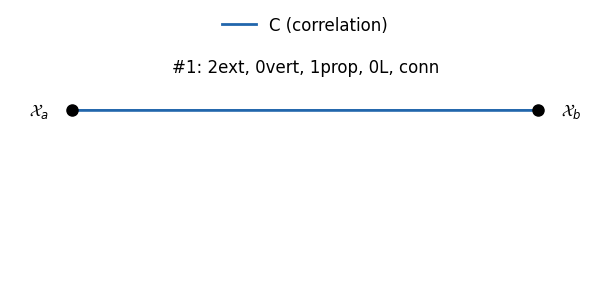

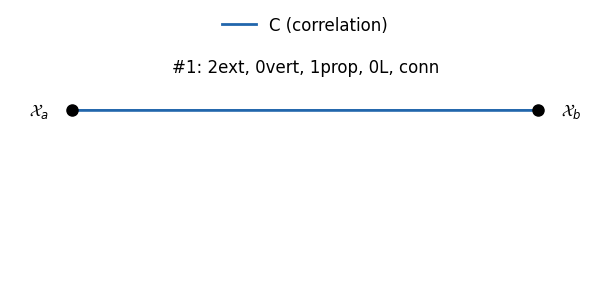

In [13]:
result.draw_diagrams(order=0, external_label_fn=mathcal_x_external_label)


### Order 2 — F·F, F·K, and K·K contributions


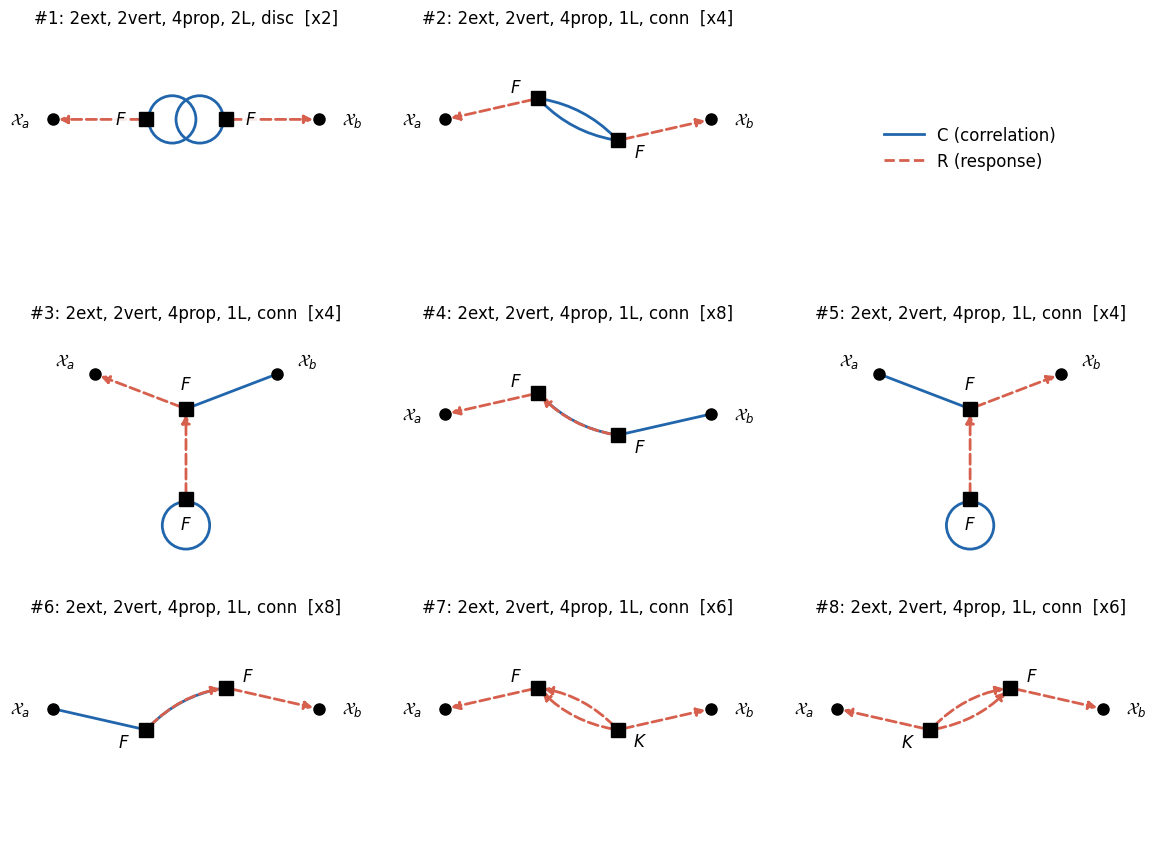

In [14]:
result.draw_diagrams(order=2, figsize=(4, 3.0), external_label_fn=mathcal_x_external_label, ncols=3)

In [15]:
fig1 = result.draw_diagrams(order=2, figsize=(4, 3.0), external_label_fn=mathcal_x_external_label, ncols=3)
fig1.savefig("./FeynDiag_2pt_order2.pdf", bbox_inches='tight')

### Order 2 — F-only action for comparison

Same 2-point function, now with $v_2$ dropped. The two F·K
diagrams disappear; only the six pure-$F$ one-loop-like
topologies remain.


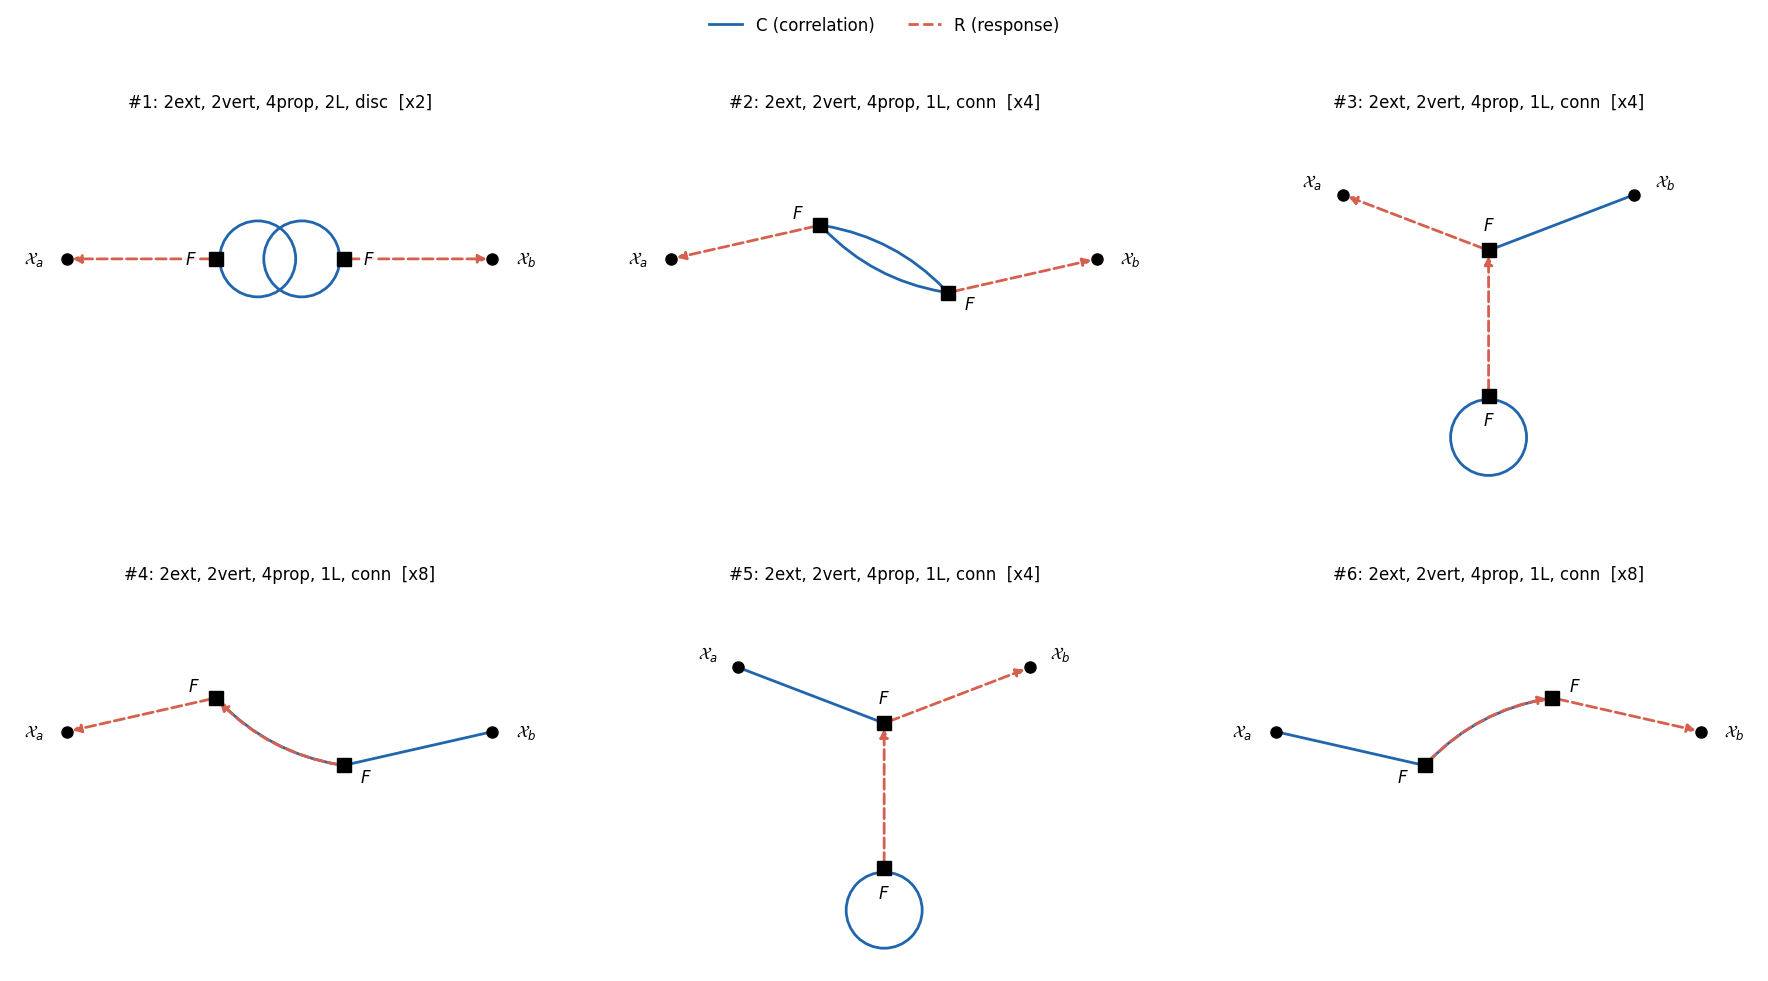

In [16]:
result_F.draw_diagrams(order=2, external_label_fn=mathcal_x_external_label)


## 6. Bonus — first-order three-point function

The same mixed local/non-local action also gives a compact example of
the first non-zero three-point function
$\langle \mathcal{X}_a(x)\,\mathcal{X}_b(y)\,\mathcal{X}_c(z) \rangle_S$.

At order 0 the Gaussian moment vanishes because it contains an odd
number of physical fields. At order 1, both vertices contribute:

- the local $F\,\psi\mathcal{X}\mathcal{X}$ vertex gives diagrams with one $R$ line
  and two $C$ lines;
- the non-local $K\,\psi\psi\psi$ vertex gives the pure three-response
  tree, one $R$ line from each external leg into a separate $K$ leg.


In [17]:
from collections import Counter

obs_3pt = [X('a', 'x'), X('b', 'y'), X('c', 'z')]
result_3pt = compute_moment(
    obs_3pt,
    action,
    order=1,
    response_phase=True,
)

for n in range(2):
    dts = result_3pt.diagram_terms(n)
    counts = Counter(
        '+'.join(sorted({sym.name for sym in _collect_coupling_symbols(dt)}))
        or '(none)'
        for dt in dts
    )
    print(f'order {n}: {len(dts)} diagram term(s), by coupling = {dict(counts)}')


order 0: 0 diagram term(s), by coupling = {}
order 1: 7 diagram term(s), by coupling = {'F': 6, 'K': 1}


Inspect the propagator content before drawing. The six local-$F$
terms differ by which external leg is attached to the response leg
and by whether the two physical legs at the vertex form a tadpole.
The single $K$ term is the fully non-local $R R R$ topology.


In [18]:
order1_3pt = result_3pt.diagram_terms(1)

for i, dt in enumerate(order1_3pt):
    couplings = sorted({sym.name for sym in _collect_coupling_symbols(dt)})
    kind = '+'.join(couplings) if couplings else '(none)'
    print(f'[{i}] couplings={kind}, n_R={dt.n_response}, '
          f'propagators={[p.to_latex() for p in dt.propagators]}')


[0] couplings=F, n_R=1, propagators=['R_{ai_{0}}(x, y_{0})', 'C_{bi_{1}}(y, y_{0})', 'C_{i_{2}c}(y_{0}, z)']
[1] couplings=F, n_R=1, propagators=['R_{ai_{0}}(x, y_{0})', 'C_{bc}(y, z)', 'C_{i_{1}i_{2}}(y_{0}, y_{0})']
[2] couplings=F, n_R=1, propagators=['R_{bi_{0}}(y, y_{0})', 'C_{ai_{1}}(x, y_{0})', 'C_{i_{2}c}(y_{0}, z)']
[3] couplings=F, n_R=1, propagators=['R_{bi_{0}}(y, y_{0})', 'C_{ac}(x, z)', 'C_{i_{1}i_{2}}(y_{0}, y_{0})']
[4] couplings=F, n_R=1, propagators=['R_{ci_{0}}(z, y_{0})', 'C_{ab}(x, y)', 'C_{i_{1}i_{2}}(y_{0}, y_{0})']
[5] couplings=F, n_R=1, propagators=['R_{ci_{0}}(z, y_{0})', 'C_{ai_{1}}(x, y_{0})', 'C_{bi_{2}}(y, y_{0})']
[6] couplings=K, n_R=3, propagators=['R_{ai_{0}}(x, y_{0})', 'R_{bi_{1}}(y, y_{1})', 'R_{ci_{2}}(z, y_{2})']


### Draw the order-1 three-point diagrams


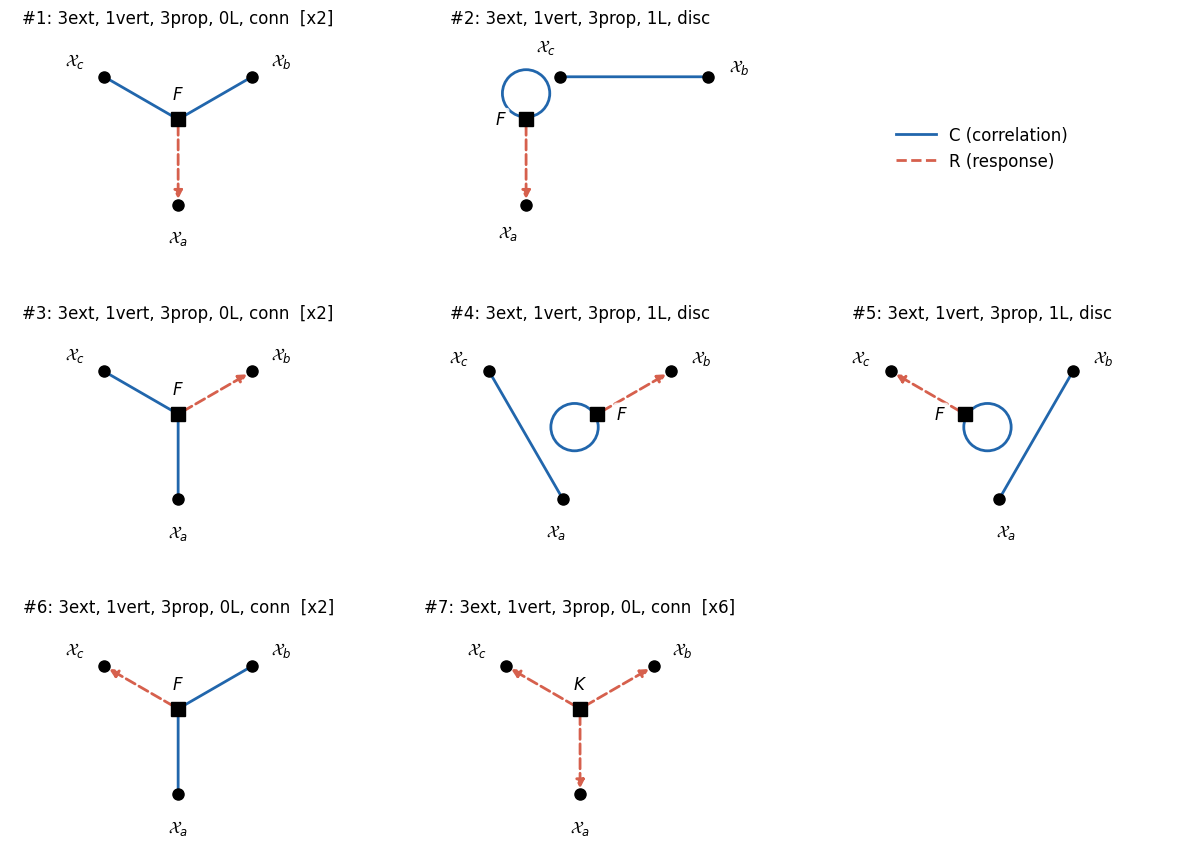

In [19]:
result_3pt.draw_diagrams(
    order=1,
    figsize=(4, 3),
    ncols=3,
    external_label_fn=mathcal_x_external_label,
)

In [20]:
fig2 = result_3pt.draw_diagrams(
    order=1,
    figsize=(4, 3),
    ncols=3,
    external_label_fn=mathcal_x_external_label,
)
fig2.savefig("./FeynDiag_3pt_order1.pdf", bbox_inches='tight')